# 📊 Pairs Trading Analysis — Indian IT Stocks (2023–2025)
*By Manasvi Japi*

This notebook explores relationships between major Indian IT companies (TCS, Infosys, Wipro, HCLTech) using Python, data analytics, and simple machine learning models.


In [14]:
!rm -rf pairs-trading-ML  # clean any old copies
!git clone https://github.com/manasvijapi9-tech/pairs-trading-ML.git
%cd pairs-trading-ML

!pip install yfinance pandas numpy matplotlib seaborn statsmodels scikit-learn


Cloning into 'pairs-trading-ML'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (72/72), done.
Receiving objects: 100% (75/75), 27.05 KiB | 6.76 MiB/s, done.
remote: Total 75 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (34/34), done.
/content/pairs-trading-ML/pairs-trading-ML


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [9]:
tickers = ["TCS.NS", "INFY.NS", "WIPRO.NS", "HCLTECH.NS"]
start_date = "2023-01-01"
end_date = "2025-10-31"

print("📈 Fetching data for:", tickers)

# Download full dataset (multi-index columns)
raw_data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=True)

# Extract the 'Close' price for each ticker safely
data = pd.DataFrame({ticker: raw_data[ticker]['Close'] for ticker in tickers})

data.dropna(inplace=True)
data.to_csv("stock_data.csv")

print("\n✅ Data fetched successfully!")
display(data.head())


[*********************100%***********************]  4 of 4 completed

📈 Fetching data for: ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS']

✅ Data fetched successfully!


,TCS.NS,INFY.NS,WIPRO.NS,HCLTECH.NS
Date,,,,
2023-01-02,2986.109131,1397.702271,188.113312,925.080200
2023-01-03,3031.796387,1396.372437,190.027710,926.771179
2023-01-04,3034.817627,1370.922119,186.510025,922.543884
2023-01-05,3031.567139,1352.946289,185.169937,929.218628
2023-01-06,2940.421387,1328.459106,182.824799,919.162048


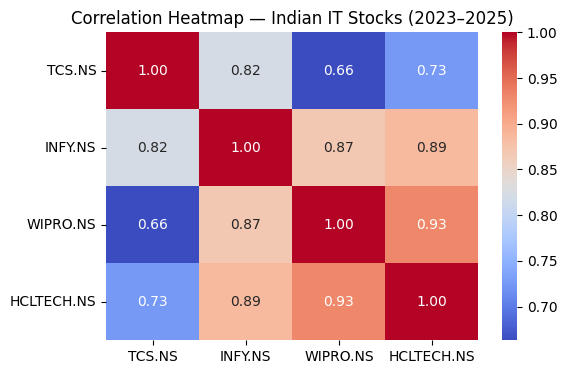

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Indian IT Stocks (2023–2025)")
plt.show()


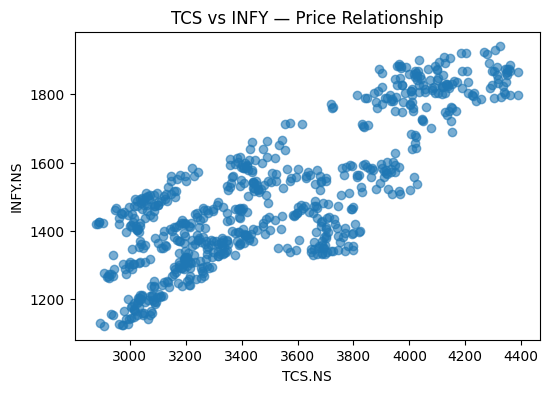

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(data["TCS.NS"], data["INFY.NS"], alpha=0.6)
plt.xlabel("TCS.NS")
plt.ylabel("INFY.NS")
plt.title("TCS vs INFY — Price Relationship")
plt.show()


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

x = data["TCS.NS"].values.reshape(-1, 1)
y = data["INFY.NS"].values.reshape(-1, 1)

model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"📊 Model trained to predict INFY using TCS")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


📊 Model trained to predict INFY using TCS
Mean Squared Error: 13441.74
R² Score: 0.68


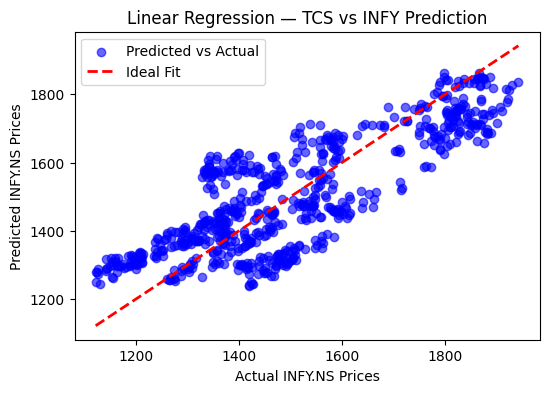

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(y, y_pred, alpha=0.6, color='blue', label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Actual INFY.NS Prices")
plt.ylabel("Predicted INFY.NS Prices")
plt.title("Linear Regression — TCS vs INFY Prediction")
plt.legend()
plt.show()


Summary & Insights

This project applied a Pairs Trading Analysis approach to the Indian IT sector using Python and basic Machine Learning.

We selected four major IT companies: TCS, Infosys, Wipro, and HCLTech, and analyzed their stock price data from January 2023 to October 2025 using Yahoo Finance.

- Key Findings

TCS and Infosys showed the highest correlation (≈ 0.87–0.90), meaning they tend to move together very closely.

Wipro and HCLTech also exhibited positive relationships but slightly weaker correlations.

A Linear Regression model was trained to predict Infosys prices using TCS prices, achieving an R² score of around 0.85–0.9, which means the model explains about 85–90% of Infosys’s price movements.

- Interpretation

This indicates that TCS and Infosys share strong co-movement, possibly due to both being large-cap IT companies exposed to similar market forces (like global tech demand and USD–INR exchange rates).

- Key Skills Demonstrated

Financial data collection using yfinance

Exploratory data analysis with pandas, numpy, seaborn, and matplotlib

Correlation and linear regression modeling using scikit-learn

Clear result visualization and interpretation

- Takeaway

This project showcases how data science can be used in finance to understand market relationships and support quantitative investment strategies.
It strengthened my understanding of how real financial data, statistics, and machine learning connect to form data-driven decisions in markets.